## Исследуем регрессионную проблему общего вида

### Цель работы
Познакомиться с основными приемами работы с моделями регрессии в scikit-learn.

#### Содержание
1. Загрузка датасета о ценах на недвижимость в Калифорнии.
3. Построение модели регрессии для предсказания цены конкретного объекта.
4. Оценка качества построенной модели с помощью визуализации и коэффициента детерминации.
5. Постройте альтернативную полиномиальную модель, сравните ее с предыдущей.
6. Исследуем проблемы с данными (неправильное обучение, отсутствие нормирования) 


In [3]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

### Загрузим исходный набор данных:

In [4]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

Описание:
https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html

In [5]:
type(california)

sklearn.utils._bunch.Bunch

Это специальный тип данных библиотеки sklearn, который похож по своему устройству на обычный словарь. Поэтому посмотрим, какие ключи есть в этом словаре:

In [6]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [7]:
print(california.data.shape, california.target.shape)

(20640, 8) (20640,)


Получается, что в данных более 20 тысяч строк и 8 атрибутов. Дополнительно можно еще вывести описание датасета для получения дополнительной информации.

Теперь с данными можно работать разными способами. Для удобства анализа мы объединим все массивы в датафрейм:

In [8]:
data = pd.DataFrame(california.data, columns = california.feature_names)
data['Price'] = california.target
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Количественные и качественные характеристики датасета

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [10]:
data.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


### Делим данные по фичам

In [11]:
y = data['Price']
X = data.drop('Price', axis=1)

In [12]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [13]:
#%%timeit

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
### Коэффициенты линейной регрессии:

In [15]:
print("Coefficients: \n", model.coef_)

Coefficients: 
 [ 4.36693293e-01  9.43577803e-03 -1.07322041e-01  6.45065694e-01
 -3.97638942e-06 -3.78654265e-03 -4.21314378e-01 -4.34513755e-01]


In [16]:
_ = [print(k, v) for k, v in zip(X.columns, model.coef_)]

MedInc 0.43669329313432376
HouseAge 0.009435778033238274
AveRooms -0.1073220413909034
AveBedrms 0.6450656935198094
Population -3.976389421230658e-06
AveOccup -0.0037865426549710313
Latitude -0.42131437752714446
Longitude -0.4345137546747767


In [17]:
print("Intercept: \n", model.intercept_)

Intercept: 
 -36.94192020718428


Сделаем предсказания модели и выведем на экран первые несколько точек:

In [18]:
y_pred = model.predict(X)
print(y_pred[:5])

[4.13164983 3.97660644 3.67657094 3.2415985  2.41358744]


Для сравнения выведем реальные соответствующие значения целевой переменной:

In [19]:
print(y[:5])

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64


Конечно, так анализировать данные неудобно. Лучше построить график, демонстрирующий связь между реальными и предсказанными значениями целевой переменной:

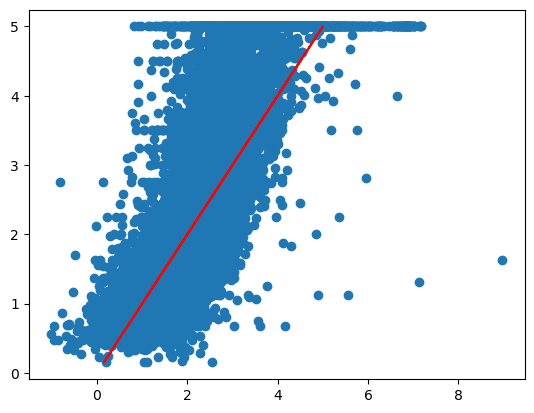

In [20]:
plt.scatter(y_pred, y)
plt.plot(y, y, c='r')

Коэффициенту детерминации:

In [21]:
model.score(X, y)

0.606232685199805

Уровень 0.6 показывает, что модель могла бы быть более точной. Давайте попробуем построить другую модель - полиномиальную регрессию. Есть надежда, что введение полиномиальных признаков может существенно увеличить точность модели:

In [22]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(3).fit_transform(X)
len(poly[0])

165

In [23]:
#№%%timeit
polynomial = LinearRegression()
polynomial.fit(poly, y)
y_pred_poly = polynomial.predict(poly)

In [24]:
poly.shape, y.shape

((20640, 165), (20640,))

In [25]:
polynomial.score(poly, y)

0.7286583856209099

Скор улучшился

### Попробуем другие модели 

In [26]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X, y)
y_pred = knn.predict(X)
knn.score(X, y)


0.471118594496435

### Нужно разделять выборку на тренировочную и тестовую

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [28]:
knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
knn.score(X_test, y_test)

0.14103588092312214

А что у нас с расстоянием?

In [29]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [30]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
knn.score(X_test_scaled, y_test)

0.7022687992254846

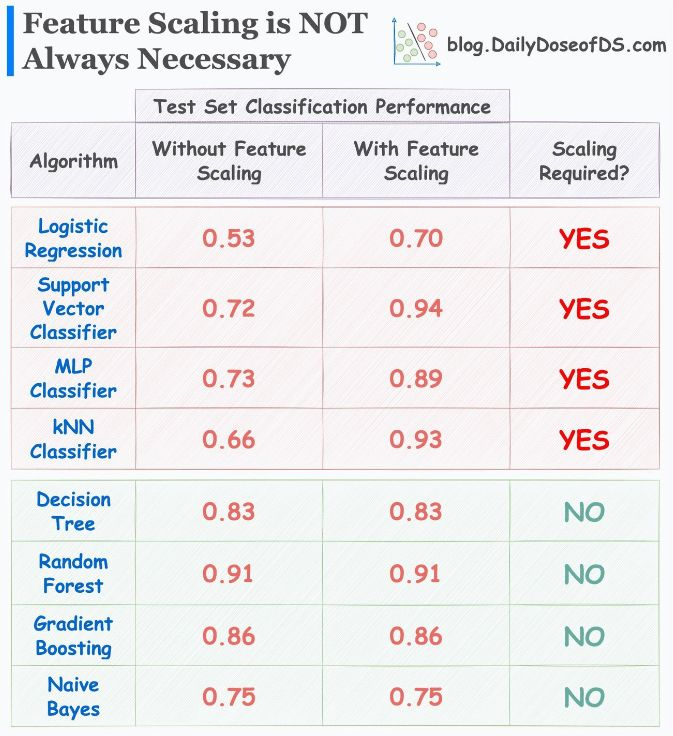

In [32]:
from IPython.display import Image
Image("sources/1758450178080.jpeg")

In [33]:
# Попробовать дерево решений
# Попробовать ансамбль
# Ппоробовать catboost / lightgbm / xgboost

In [34]:
# 